In [1]:

!pip install groq fpdf2 pillow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 16.0 MB/s eta 0:00:00


In [2]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:


GROQ_API_KEY     = "gsk_your_groq_api_key_here"  # <-- paste your key here

LOADING MODELS
✅ Models loaded

RUNNING FULL PIPELINE - FIRST IMAGE ONLY
Found 4 images - processing first one only

Processing: test_glioma.jpg
[STEP 1] Classification...
  ✅ glioma (96.57%)
[STEP 2] Segmentation...
  ✅ Mask generated
[STEP 3] GradCAM...
  ✅ Heatmap generated
[STEP 4] Computing Metrics...
  ✅ Area:12.0875cm2 | Vol:6.044cm3 | Sev:Severe | Risk:Moderate
[STEP 5] Generating Report via Groq...
  ✅ Report generated
  📄 PDF saved: /content/sample_data/test_glioma_20260314051450_mri_report.pdf


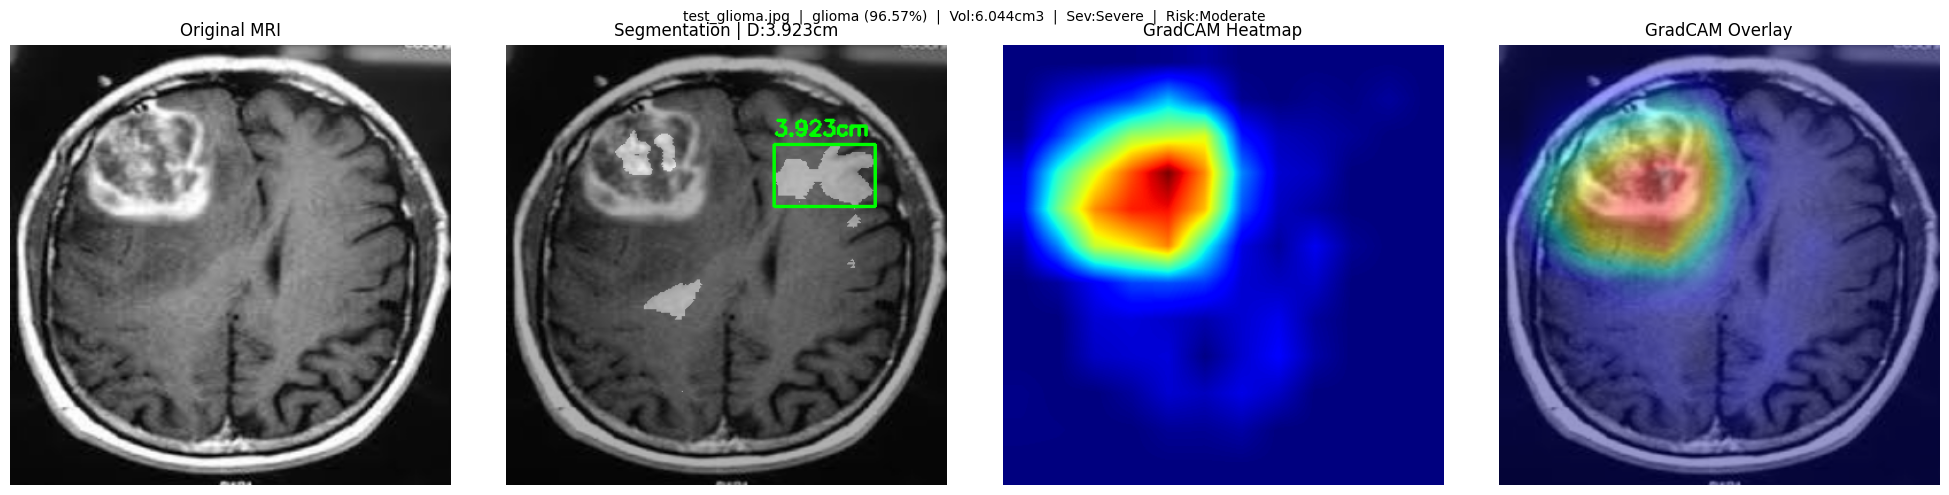


FINAL SUMMARY
  Total Processed : 1 of 4
  ✅ Passed       : 1
  ❌ Failed       : 0
  📁 Report saved : /content/sample_data


In [4]:

import os, warnings, time, re
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import cv2, numpy as np, tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as effv2_prep
from datetime import datetime
from fpdf import FPDF
import base64
from groq import Groq

# ════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════
BASE_DIR         = "/content/drive/MyDrive/Project work"
CLASS_MODEL_PATH = BASE_DIR + "/models/Classification/Tumor_v2s_clean.keras"
SEG_MODEL_PATH   = BASE_DIR + "/models/Segmentation/unet_lgg_segmentation_u-net.keras"
TEST_DIR         = BASE_DIR + "/Test Data"
REPORT_DIR       = "/content/sample_data"
os.makedirs(REPORT_DIR, exist_ok=True)
IMG_SIZE         = 384
SEG_SIZE         = 256
CLASS_NAMES      = ["glioma", "meningioma", "no_tumor", "pituitary"]
PIXEL_SPACING_MM = 0.5
MM2_TO_CM2       = 0.01
MRI_PARAMS = {
    "sequence":        "T1-Weighted Contrast Enhanced",
    "resolution":      "384 x 384",
    "slice_thickness": "5.0 mm",
    "field_strength":  "1.5T",
    "voxel_size":      "0.5 x 0.5 x 5.0 mm",
}

groq_client = Groq(api_key=GROQ_API_KEY)

# ════════════════════════════════════════════════════
# MODELS
# ════════════════════════════════════════════════════
print("="*50)
print("LOADING MODELS")
print("="*50)
class_model = tf.keras.models.load_model(CLASS_MODEL_PATH)
seg_model   = tf.keras.models.load_model(SEG_MODEL_PATH, compile=False)
print("✅ Models loaded")

base_model  = class_model.get_layer("efficientnetv2-s")
head_layers = []
reached     = False
for layer in class_model.layers:
    if layer.name == "efficientnetv2-s":
        reached = True; continue
    if reached:
        head_layers.append(layer)

# ════════════════════════════════════════════════════
# UNIVERSAL SANITIZER  ← fixes ALL unicode PDF crashes
# ════════════════════════════════════════════════════
def safe(text):
    if not isinstance(text, str):
        text = str(text)
    for c, r in {
        '\u2014':'-','\u2013':'-','\u2012':'-','\u2010':'-','\u2011':'-',
        '\u2018':"'",'\u2019':"'",'\u201c':'"','\u201d':'"',
        '\u2022':'-','\u2026':'...','\u00b2':'2','\u00b3':'3',
        '\u00b0':' deg','\u00b1':'+/-','\u2192':'->','\u2265':'>=',
        '\u2264':'<=','\u2260':'!=','\u00b5':'u','\u00d7':'x',
    }.items():
        text = text.replace(c, r)
    return text.encode('latin-1', errors='ignore').decode('latin-1')

# ════════════════════════════════════════════════════
# HELPERS
# ════════════════════════════════════════════════════
def load_class_image(path):
    img = tf.keras.utils.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    img = tf.keras.utils.img_to_array(img)
    img = effv2_prep(img)
    return np.expand_dims(img, axis=0)

def get_gradcam_heatmap(img_tensor):
    img_tensor_cast = tf.cast(img_tensor, tf.float32)
    conv_output     = base_model(img_tensor_cast, training=False)
    conv_var        = tf.Variable(conv_output)
    with tf.GradientTape() as tape:
        tape.watch(conv_var)
        x = conv_var
        for layer in head_layers:
            x = layer(x)
        class_score = x[:, tf.argmax(x[0])]
    grads = tape.gradient(class_score, conv_var)
    if grads is None:
        return np.zeros((12, 12))
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    hmap   = conv_output[0] @ pooled[..., tf.newaxis]
    hmap   = tf.squeeze(hmap)
    hmap   = tf.maximum(hmap, 0) / (tf.math.reduce_max(hmap) + 1e-8)
    return hmap.numpy()

def estimate_tumor_size(mask):
    tp    = int(np.sum(mask))
    tot   = mask.shape[0] * mask.shape[1]
    amm2  = tp * (PIXEL_SPACING_MM**2)
    acm2  = amm2 * MM2_TO_CM2
    dcm   = (2 * np.sqrt(amm2 / np.pi)) / 10
    pct   = (tp / (tot * 0.60)) * 100
    vol   = acm2 * (5.0/10)
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bbox  = None
    if cnts:
        x,y,w,h = cv2.boundingRect(max(cnts, key=cv2.contourArea))
        bbox = {"x":x,"y":y,"w":w,"h":h,
                "width_cm":round(w*PIXEL_SPACING_MM/10,2),
                "height_cm":round(h*PIXEL_SPACING_MM/10,2)}
    return {"tumor_pixels":tp,"area_mm2":round(amm2,2),"area_cm2":round(acm2,4),
            "diameter_cm":round(dcm,3),"tumor_percent":round(pct,2),
            "volume_cm3":round(vol,3),"bbox":bbox}

def analyze_tumor_shape(mask):
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None
    lg   = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(lg)
    peri = cv2.arcLength(lg, True)
    if area==0 or peri==0: return None
    irr  = min(round(1-(4*np.pi*area)/(peri**2),3),1.0)
    comp = round((peri**2)/(4*np.pi*area),3)
    hull = cv2.convexHull(lg)
    conv = round(area/cv2.contourArea(hull),3) if cv2.contourArea(hull)>0 else 1.0
    ecc  = 0.0
    if len(lg)>=5:
        el  = cv2.fitEllipse(lg)
        a,b = el[1][0]/2, el[1][1]/2
        if max(a,b)>0: ecc = round(np.sqrt(1-(min(a,b)/max(a,b))**2),3)
    bdef = "Poorly defined" if irr>0.5 else ("Moderately defined" if irr>0.3 else "Well-defined")
    rough= "High" if irr>0.5 else ("Moderate" if irr>0.3 else "Low")
    return {"irregularity":irr,"compactness":comp,"convexity":conv,
            "eccentricity":ecc,"border_def":bdef,"roughness":rough}

def detect_mass_effect(mask):
    h,w  = mask.shape
    mid  = w//2
    lt   = int(np.sum(mask[:,:mid]))
    rt   = int(np.sum(mask[:,mid:]))
    tot  = lt+rt
    lat  = "None"
    smm  = 0.0
    if tot>0:
        r   = lt/tot
        lat = "Left hemisphere" if r>0.6 else ("Right hemisphere" if r<0.4 else "Bilateral/Midline")
        smm = round(abs(lt-rt)*(PIXEL_SPACING_MM**2)/(h*PIXEL_SPACING_MM),2)
    comp = "Moderate" if smm>5 else ("Mild" if smm>2 else "None")
    sulf = "Present" if smm>2 else "Absent"
    return {"laterality":lat,"shift_mm":smm,"compression":comp,"sulcal":sulf}

def compute_risk_score(label, confidence, size_info, shape_info, mass_info):
    if label=="no_tumor": return {"score":0.0,"risk":"None","progression_risk":"0%"}
    s  = min(confidence,1.0)*0.25
    s += min(size_info['tumor_percent']/30,1.0)*0.20
    s += min(size_info['volume_cm3']/20,1.0)*0.20
    if shape_info:
        s += shape_info['irregularity']*0.15
        s += (1-shape_info['convexity'])*0.10
    s += min(mass_info['shift_mm']/10,1.0)*0.10
    s  = round(min(s, 1.0), 3)
    risk = "High" if s>0.7 else ("Moderate" if s>0.4 else "Low")
    prog = f"{int(s*100)}%" if s>0.7 else (f"{int(s*80)}%" if s>0.4 else f"{int(s*60)}%")
    return {"score":s,"risk":risk,"progression_risk":prog}

def compute_confidence_calibration(confidence):
    u = round((1-confidence)*0.5+0.01,3)
    return {"uncertainty":f"+/-{round(u*100,1)}%","cal_score":round(1-u,3)}

def get_severity(label, confidence, tumor_percent):
    if label=="no_tumor": return "None"
    if tumor_percent>20 or confidence>0.95: return "Severe"
    if tumor_percent>10 or confidence>0.80: return "Moderate"
    return "Mild"

def get_recommendation(label, severity):
    if label=="no_tumor": return "No tumor detected. Routine follow-up recommended."
    return {"Mild":"Follow-up MRI in 3 months. Neurology consult.",
            "Moderate":"Urgent neurology consultation within 2 weeks.",
            "Severe":"Immediate neurosurgical referral required."}.get(severity,"Consult specialist.")

def get_clinical_decision(label, severity, mass_info):
    if label=="no_tumor":
        return {"steps":["Routine follow-up in 12 months","No immediate action required"],"urgency":"Low"}
    steps = ["Neurosurgical consultation","Contrast MRI follow-up"]
    if severity=="Severe":
        steps += ["MR Spectroscopy","Perfusion MRI","Surgical planning","Biopsy / Histopathology"]
        urg = "Critical"
    elif severity=="Moderate":
        steps += ["MR Spectroscopy","Neuropsychological assessment"]
        urg = "High"
    else:
        steps += ["PET scan consideration","Neurological evaluation"]
        urg = "Moderate"
    if mass_info['shift_mm']>3: steps.append("Immediate review for mass effect")
    return {"steps":steps,"urgency":urg}

def get_rano_assessment(label, size_info, shape_info):
    if label=="no_tumor": return None
    sc  = "Large" if size_info['diameter_cm']>3 else ("Medium" if size_info['diameter_cm']>1.5 else "Small")
    nec = "Likely present" if (shape_info and shape_info['irregularity']>0.5) else "Not clearly identified"
    enh = "Heterogeneous" if (shape_info and shape_info['irregularity']>0.4) else "Homogeneous"
    grd = "High-Grade (imaging features suggest possible high-grade - histopathological confirmation required)"
    if size_info['diameter_cm']<2 and (not shape_info or shape_info['irregularity']<0.3):
        grd = "Low-Grade (imaging features suggest possible low-grade - histopathological confirmation required)"
    return {"size_cat":sc,"enhancement":enh,"necrosis":nec,"grade":grd}

def clean_llm_text(text):
    text = re.sub(r'#{1,6}\s*','',text)
    text = re.sub(r'\*\*(.*?)\*\*',r'\1',text)
    text = re.sub(r'\*(.*?)\*',r'\1',text)
    text = re.sub(r'`(.*?)`',r'\1',text)
    return safe(text)

# ════════════════════════════════════════════════════
# GROQ
# ════════════════════════════════════════════════════
def generate_llm_report(image_path, label, confidence, size_info, shape_info,
                         mass_info, risk_info, severity, recommendation, rano):
    with open(image_path,"rb") as f:
        img_b64 = base64.b64encode(f.read()).decode("utf-8")
    bbox_t = f"{size_info['bbox']['width_cm']} cm x {size_info['bbox']['height_cm']} cm" if size_info['bbox'] else "N/A"
    rano_t = "" if not rano else f"\n- RANO Size: {rano['size_cat']}\n- Enhancement: {rano['enhancement']}\n- Necrosis: {rano['necrosis']}"
    shape_t= "" if not shape_info else f"\n- Irregularity: {shape_info['irregularity']}\n- Border: {shape_info['border_def']}"
    prompt = f"""You are an expert radiologist AI assistant.

AI FINDINGS:
- Type: {label} | Confidence: {confidence:.2%} | Severity: {severity}
- Area: {size_info['area_cm2']} cm2 | Diameter: {size_info['diameter_cm']} cm | Volume: {size_info['volume_cm3']} cm3
- Brain Coverage: {size_info['tumor_percent']}% | Bounding Box: {bbox_t}
- Laterality: {mass_info['laterality']} | Midline Shift: {mass_info['shift_mm']} mm
- Risk Score: {risk_info['score']} | Growth Risk: {risk_info['risk']}
{shape_t}{rano_t}

Write a structured radiology report with these exact 6 sections:
1. CLINICAL INDICATION
2. IMAGING TECHNIQUE
3. FINDINGS
4. IMPRESSION
5. SEVERITY ASSESSMENT
6. RECOMMENDATIONS

STRICT RULES:
- Plain ASCII only. No em dashes, smart quotes, markdown, bullets, or special symbols.
- Never confirm tumor grade. Say imaging features suggest possible grade only.
- Always state histopathological confirmation is required.
- Keep each section to 2-4 sentences. Total report under 300 words."""
    resp = groq_client.chat.completions.create(
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        messages=[{"role":"user","content":[
            {"type":"image_url","image_url":{"url":f"data:image/jpeg;base64,{img_b64}"}},
            {"type":"text","text":prompt}
        ]}],
        max_tokens=1000
    )
    return clean_llm_text(resp.choices[0].message.content)

# ════════════════════════════════════════════════════
# RISK CHART — redesigned, higher DPI, better styling
# ════════════════════════════════════════════════════
def generate_risk_chart(size_info, risk_info, shape_info, mass_info):
    """Generate a polished 3-panel risk analytics chart saved as high-res JPEG."""
    import matplotlib.patches as mpatches

    DARK   = '#14284A'   # header navy
    RED    = '#C0392B'
    ORANGE = '#E67E22'
    GREEN  = '#27AE60'
    BLUE   = '#2980B9'
    PURPLE = '#8E44AD'
    TEAL   = '#16A085'
    BG     = '#F5F7FA'

    def risk_color(v):
        if v > 0.6: return RED
        if v > 0.3: return ORANGE
        return GREEN

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
    fig.patch.set_facecolor('#FFFFFF')

    tp = max(min(size_info['tumor_percent'], 100), 0)

    # ── Chart 1: Donut — Tumor vs Brain ─────────────
    ax = axes[0]
    ax.set_facecolor('#FFFFFF')
    sizes  = [tp, 100 - tp]
    colors = [RED, GREEN]
    wedges, texts, autotexts = ax.pie(
        sizes,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.78,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
        textprops={'fontsize': 7.5, 'color': '#333333'}
    )
    for at in autotexts:
        at.set_fontsize(7)
        at.set_fontweight('bold')
        at.set_color('white')
    # Centre label
    ax.text(0, 0, f"{tp:.1f}%\nTumor", ha='center', va='center',
            fontsize=8, fontweight='bold', color=DARK)
    ax.set_title('Tumor vs Brain Coverage', fontsize=9, fontweight='bold',
                 color=DARK, pad=8)
    legend_items = [
        mpatches.Patch(facecolor=RED,   label='Tumor'),
        mpatches.Patch(facecolor=GREEN, label='Healthy Brain'),
    ]
    ax.legend(handles=legend_items, fontsize=6.5, loc='lower center',
              bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

    # ── Chart 2: Horizontal bar — Risk Factors ───────
    ax = axes[1]
    ax.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_color('#DDDDDD')

    cats = ['Mass Effect', 'Shape', 'Size', 'Confidence']
    vals = [
        round(min(mass_info['shift_mm'] / 10, 1.0), 2),
        round(shape_info['irregularity'] if shape_info else 0, 2),
        round(min(size_info['tumor_percent'] / 30, 1.0), 2),
        round(min(risk_info['score'] * 1.2, 1.0), 2),
    ]
    bar_colors = [risk_color(v) for v in vals]

    bars = ax.barh(cats, vals, color=bar_colors, height=0.45,
                   edgecolor='white', linewidth=0.8)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel('Score (0-1)', fontsize=7, color='#555555')
    ax.tick_params(axis='y', labelsize=7.5)
    ax.tick_params(axis='x', labelsize=6.5)
    ax.set_title('Risk Factor Analysis', fontsize=9, fontweight='bold',
                 color=DARK, pad=8)

    # Background reference lines
    for x in [0.3, 0.6]:
        ax.axvline(x, color='#CCCCCC', linewidth=0.8, linestyle='--')

    for bar, v in zip(bars, vals):
        ax.text(min(v + 0.03, 0.97), bar.get_y() + bar.get_height() / 2,
                f'{v:.2f}', va='center', ha='left', fontsize=7,
                fontweight='bold', color='#333333')

    # Legend for risk zones
    zone_patches = [
        mpatches.Patch(facecolor=RED,    label='High   > 0.6'),
        mpatches.Patch(facecolor=ORANGE, label='Mod    > 0.3'),
        mpatches.Patch(facecolor=GREEN,  label='Low   <= 0.3'),
    ]
    ax.legend(handles=zone_patches, fontsize=6, loc='lower right',
              frameon=True, framealpha=0.85)

    # ── Chart 3: Grouped bar — Shape Metrics ────────
    ax = axes[2]
    ax.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_color('#DDDDDD')

    if shape_info:
        labels = ['Irregularity', 'Compactness\n(norm)', 'Eccentricity', 'Inv. Convexity']
        values = [
            shape_info['irregularity'],
            min(shape_info['compactness'] / 3.5, 1.0),
            shape_info['eccentricity'],
            round(1 - shape_info['convexity'], 3),
        ]
        bar_cols = [PURPLE, BLUE, TEAL, ORANGE]
        x_pos = range(len(labels))
        bars2  = ax.bar(x_pos, values, color=bar_cols, width=0.55,
                        edgecolor='white', linewidth=0.8)
        ax.set_xticks(list(x_pos))
        ax.set_xticklabels(labels, fontsize=6.2, ha='center')
        ax.set_ylim(0, 1.1)
        ax.set_ylabel('Score', fontsize=7, color='#555555')
        ax.tick_params(axis='y', labelsize=6.5)

        for bar, v in zip(bars2, values):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.025,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7,
                    fontweight='bold', color='#333333')

        # Threshold line at 0.5
        ax.axhline(0.5, color='#AAAAAA', linewidth=0.8, linestyle='--')
        ax.text(3.5, 0.52, 'Threshold', fontsize=5.5, color='#999999')
    else:
        ax.text(0.5, 0.5, 'No tumor detected', ha='center', va='center',
                fontsize=10, color='#888888', transform=ax.transAxes)

    ax.set_title('Tumor Shape Metrics', fontsize=9, fontweight='bold',
                 color=DARK, pad=8)

    fig.suptitle('Tumor Risk Analytics', fontsize=11, fontweight='bold',
                 color=DARK, y=1.02)

    plt.tight_layout(pad=1.5)

    os.makedirs("/tmp/report_imgs", exist_ok=True)
    chart_path = "/tmp/report_imgs/risk_chart.jpg"
    plt.savefig(chart_path, dpi=150, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.close()
    return chart_path
# ════════════════════════════════════════════════════
# PDF REPORT — redesigned professional 3-page layout
# ════════════════════════════════════════════════════
def save_pdf_report(filename, image_path, label, confidence, size_info,
                    shape_info, mass_info, risk_info, cal_info, severity,
                    recommendation, llm_report, clinical, rano,
                    orig, mask_overlay, heatmap, gradcam_overlay):

    # ── Colour palette ───────────────────────────────
    NAV    = (20,  40,  80)   # header navy
    NAV_L  = (44,  72, 120)   # lighter navy for sub-bars
    SEV_C  = {"Severe":(192,57,43),"Moderate":(211,84,0),
               "Mild":(39,174,96),"None":(39,174,96)}
    SC     = SEV_C.get(severity,(80,80,80))
    GREY   = (245,248,252)    # card background
    LGREY  = (210,218,230)    # card border
    TEXT   = (30,  30,  40)   # body text
    WHITE  = (255,255,255)
    MUTED  = (120,130,145)

    pdf = FPDF()
    pdf.set_auto_page_break(auto=False)

    # ════════════════════════════════
    # HELPER FUNCTIONS
    # ════════════════════════════════
    def draw_header(title_left, title_right="", subtitle=""):
        """Full-width navy header bar with title."""
        pdf.set_fill_color(*NAV)
        pdf.rect(0, 0, 210, 20, 'F')
        # Accent stripe
        pdf.set_fill_color(*SC)
        pdf.rect(0, 20, 210, 2, 'F')
        pdf.set_text_color(*WHITE)
        pdf.set_font("Helvetica", "B", 13)
        pdf.set_xy(10, 5)
        pdf.cell(130, 9, title_left, ln=False)
        if title_right:
            pdf.set_font("Helvetica", "", 7.5)
            pdf.set_xy(145, 7)
            pdf.cell(55, 5, safe(title_right))
        if subtitle:
            pdf.set_font("Helvetica", "I", 7)
            pdf.set_xy(10, 14)
            pdf.set_text_color(200, 210, 230)
            pdf.cell(190, 4, safe(subtitle))
        pdf.set_text_color(*TEXT)

    def draw_footer(page_num, total_pages=3):
        pdf.set_fill_color(*NAV)
        pdf.rect(0, 282, 210, 15, 'F')
        pdf.set_text_color(*WHITE)
        pdf.set_font("Helvetica", "I", 6.5)
        pdf.set_xy(10, 285.5)
        pdf.cell(155, 4, "AI-generated report. Must be reviewed by a qualified medical professional before clinical use.")
        pdf.set_font("Helvetica", "B", 7.5)
        pdf.set_xy(165, 285)
        pdf.cell(35, 5, f"Page {page_num} / {total_pages}", align="R")
        pdf.set_text_color(*TEXT)

    def section_bar(title, y, color=None):
        """Dark navy section header bar, returns new y."""
        c = color or NAV
        pdf.set_fill_color(*c)
        pdf.rect(10, y, 190, 6, 'F')
        pdf.set_text_color(*WHITE)
        pdf.set_font("Helvetica", "B", 7.5)
        pdf.set_xy(13, y + 0.8)
        pdf.cell(186, 5, safe(f"  {title}"))
        pdf.set_text_color(*TEXT)
        return y + 7

    def card(x, y, w, h):
        """Rounded-corner-ish card background."""
        pdf.set_fill_color(*GREY)
        pdf.set_draw_color(*LGREY)
        pdf.rect(x, y, w, h, 'FD')

    def kv(x, y, key, val, kw=32, vw=30, rh=4.5, val_bold=False, val_color=None):
        """Key:Value field pair."""
        pdf.set_xy(x, y)
        pdf.set_font("Helvetica", "B", 7)
        pdf.set_text_color(*MUTED)
        pdf.cell(kw, rh, safe(f"{key}:"), ln=False)
        pdf.set_font("Helvetica", "B" if val_bold else "", 7.5)
        pdf.set_text_color(*(val_color or TEXT))
        pdf.cell(vw, rh, safe(str(val)), ln=False)
        pdf.set_text_color(*TEXT)

    def badge(x, y, text, rgb):
        """Coloured inline badge."""
        pdf.set_fill_color(*rgb)
        pdf.set_text_color(*WHITE)
        pdf.set_font("Helvetica", "B", 7.5)
        w = pdf.get_string_width(text) + 6
        pdf.rect(x, y, w, 5.5, 'F')
        pdf.set_xy(x + 1, y + 0.5)
        pdf.cell(w - 2, 4.5, safe(text), align="C")
        pdf.set_text_color(*TEXT)
        return w

    def divider(y, color=LGREY):
        pdf.set_draw_color(*color)
        pdf.line(10, y, 200, y)

    # ════════════════════════════════
    # PAGE 1 — CLINICAL ANALYSIS
    # ════════════════════════════════
    pdf.add_page()
    draw_header("AI Brain Tumor Analysis Report",
                f"File: {filename}",
                f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}   |   Sequence: {MRI_PARAMS['sequence']}")

    # ── Severity Banner ─────────────────────────────
    pdf.set_fill_color(*SC)
    pdf.rect(10, 24, 190, 8, 'F')
    pdf.set_text_color(*WHITE)
    pdf.set_font("Helvetica", "B", 8.5)
    pdf.set_xy(10, 26)
    badge_txt = (f"  SEVERITY: {severity.upper()}   |   "
                 f"PREDICTION: {label.upper()}   |   "
                 f"CONFIDENCE: {confidence:.2%}   |   "
                 f"GROWTH RISK: {risk_info['risk'].upper()}")
    pdf.cell(190, 5, safe(badge_txt), align="C")
    pdf.set_text_color(*TEXT)

    # ── ANALYSIS SUMMARY ────────────────────────────
    y = 34
    y = section_bar("ANALYSIS SUMMARY", y)

    ROW = 6.0
    card(10, y, 190, 5 * ROW + 4)

    cols = [
        [(12,  "Tumor Type",     label.upper()),
         (12,  "Confidence",     f"{confidence:.2%}"),
         (12,  "Uncertainty",    cal_info['uncertainty']),
         (12,  "Calibration",    str(cal_info['cal_score'])),
         (12,  "Severity",       severity)],
        [(76,  "Tumor Area",     f"{size_info['area_cm2']} cm2"),
         (76,  "Diameter",       f"{size_info['diameter_cm']} cm"),
         (76,  "Est. Volume",    f"{size_info['volume_cm3']} cm3"),
         (76,  "Brain Coverage", f"{size_info['tumor_percent']}%"),
         (76,  "Bounding Box",   (f"{size_info['bbox']['width_cm']}x"
                                   f"{size_info['bbox']['height_cm']} cm")
                                  if size_info['bbox'] else "N/A")],
        [(140, "Laterality",     mass_info['laterality']),
         (140, "Midline Shift",  f"{mass_info['shift_mm']} mm"),
         (140, "Compression",    mass_info['compression']),
         (140, "Sulcal Eff.",    mass_info['sulcal']),
         (140, "Aggressiveness", f"{risk_info['score']:.3f} / 1.0")],
    ]

    for col in cols:
        for i, (cx, k, v) in enumerate(col):
            kv(cx, y + 2 + i * ROW, k, v, kw=30, vw=32)

    y += 5 * ROW + 6

    # ── VISUAL ANALYSIS ─────────────────────────────
    y = section_bar("VISUAL ANALYSIS", y)

    tmp = "/tmp/report_imgs"; os.makedirs(tmp, exist_ok=True)

    def sv(arr, name, bgr=True):
        p = f"{tmp}/{name}.jpg"
        if bgr:
            cv2.imwrite(p, arr)
        else:
            plt.imsave(p, arr, cmap="jet")
        return p

    paths = [sv(orig, "orig"), sv(mask_overlay, "mask"),
             sv(heatmap, "heatmap", bgr=False), sv(gradcam_overlay, "gcam")]
    lbls  = ["Original MRI", "Segmentation", "GradCAM Heatmap", "GradCAM Overlay"]

    iw, ih = 44, 39
    gap    = (190 - 4 * iw) / 5
    card(10, y, 190, ih + 10)

    for i, (p, l) in enumerate(zip(paths, lbls)):
        x = 10 + gap + i * (iw + gap)
        pdf.image(p, x=x, y=y + 2, w=iw, h=ih)
        pdf.set_font("Helvetica", "B", 6.5)
        pdf.set_text_color(*MUTED)
        pdf.set_xy(x, y + ih + 3)
        pdf.cell(iw, 3.5, safe(l), align="C")

    pdf.set_text_color(*TEXT)
    y += ih + 13

    # ── SHAPE | MASS | RISK ROW ─────────────────────
    y = section_bar("SHAPE ANALYSIS   |   MASS EFFECT   |   RISK SCORE", y)

    SMR_H = 30
    card(10, y, 190, SMR_H)
    RH = 5.5

    # Vertical dividers
    pdf.set_draw_color(*LGREY)
    pdf.line(74, y + 2, 74, y + SMR_H - 2)
    pdf.line(138, y + 2, 138, y + SMR_H - 2)

    # Shape column
    if shape_info:
        kv(12, y + 2,       "Irregularity", str(shape_info['irregularity']), kw=24, vw=20)
        kv(12, y + 2+RH,    "Compactness",  str(shape_info['compactness']),  kw=24, vw=20)
        kv(12, y + 2+RH*2,  "Convexity",    str(shape_info['convexity']),    kw=24, vw=20)
        kv(12, y + 2+RH*3,  "Border",       shape_info['border_def'],        kw=24, vw=20)
        kv(12, y + 2+RH*4,  "Roughness",    shape_info['roughness'],         kw=24, vw=20)

    # Mass column
    kv(78, y + 2,       "Laterality",  mass_info['laterality'],       kw=26, vw=26)
    kv(78, y + 2+RH,    "Shift",       f"{mass_info['shift_mm']} mm", kw=26, vw=26)
    kv(78, y + 2+RH*2,  "Compression", mass_info['compression'],      kw=26, vw=26)
    kv(78, y + 2+RH*3,  "Sulcal",      mass_info['sulcal'],           kw=26, vw=26)

    # Risk column — coloured values
    kv(142, y + 2,       "Aggress. Score", f"{risk_info['score']:.3f} / 1.0",
       kw=28, vw=22, val_bold=True, val_color=SC)
    kv(142, y + 2+RH,    "Growth Risk",    risk_info['risk'],
       kw=28, vw=22, val_bold=True, val_color=SC)
    kv(142, y + 2+RH*2,  "Progression",   risk_info['progression_risk'], kw=28, vw=22)
    kv(142, y + 2+RH*3,  "Uncertainty",   cal_info['uncertainty'],       kw=28, vw=22)
    y += SMR_H + 2

    # ── RANO CRITERIA ───────────────────────────────
    if rano:
        y = section_bar("RANO CRITERIA ASSESSMENT", y)
        RANO_H = 24
        card(10, y, 190, RANO_H)
        kv(12, y + 3,  "Size Category", rano['size_cat'],    kw=28, vw=28)
        kv(12, y + 11, "Enhancement",   rano['enhancement'], kw=28, vw=28)
        kv(80, y + 3,  "Necrosis",      rano['necrosis'],    kw=22, vw=44)
        pdf.set_xy(80, y + 11)
        pdf.set_font("Helvetica", "B", 7); pdf.set_text_color(*MUTED)
        pdf.cell(22, 4.5, "Grade:", ln=False)
        pdf.set_font("Helvetica", "B", 7); pdf.set_text_color(*SC)
        pdf.multi_cell(88, 4.5, safe(rano['grade']))
        pdf.set_text_color(*TEXT)
        y += RANO_H + 2

    # ── CLINICAL DECISION SUPPORT ───────────────────
    y = section_bar("CLINICAL DECISION SUPPORT", y)
    n   = len(clinical['steps'])
    mid = (n + 1) // 2
    ch  = mid * 5.5 + 14
    card(10, y, 190, ch)

    # Urgency row
    pdf.set_xy(12, y + 3)
    pdf.set_font("Helvetica", "B", 7.5)
    pdf.set_text_color(*MUTED)
    pdf.cell(30, 5, "Urgency Level:", ln=False)
    badge(42, y + 3, f"  {clinical['urgency'].upper()}  ", SC)

    # Steps in 2 columns
    for i, step in enumerate(clinical['steps']):
        col = 0 if i < mid else 1
        row = i if i < mid else i - mid
        pdf.set_xy(14 + col * 95, y + 11 + row * 5.5)
        pdf.set_font("Helvetica", "", 7.5)
        pdf.set_text_color(*TEXT)
        pdf.cell(90, 4.5, safe(f"  >>  {step}"))

    draw_footer(1)

    # ════════════════════════════════
    # PAGE 2 — RISK ANALYTICS DASHBOARD
    # ════════════════════════════════
    chart = generate_risk_chart(size_info, risk_info, shape_info, mass_info)

    pdf.add_page()
    draw_header("Risk Analytics Dashboard",
                f"File: {filename}",
                f"Prediction: {label.upper()}   |   Confidence: {confidence:.2%}   |   Severity: {severity}")

    # Intro blurb
    pdf.set_xy(10, 25)
    pdf.set_font("Helvetica", "I", 7.5)
    pdf.set_text_color(*MUTED)
    pdf.cell(190, 5, safe(
        "Quantitative breakdown of tumor characteristics derived from segmentation and classification models."))
    pdf.set_text_color(*TEXT)

    # Chart card
    y2 = 32
    card(10, y2, 190, 95)
    pdf.image(chart, x=12, y=y2 + 3, w=186, h=89)
    y2 += 99

    # ── Key Metrics Summary Strip ────────────────────
    y2 = section_bar("KEY METRICS AT A GLANCE", y2)
    STRIP_H = 24
    card(10, y2, 190, STRIP_H)

    metric_items = [
        ("Tumor Area",     f"{size_info['area_cm2']} cm2"),
        ("Diameter",       f"{size_info['diameter_cm']} cm"),
        ("Volume",         f"{size_info['volume_cm3']} cm3"),
        ("Brain Cov.",     f"{size_info['tumor_percent']}%"),
        ("Midline Shift",  f"{mass_info['shift_mm']} mm"),
        ("Risk Score",     f"{risk_info['score']:.3f} / 1.0"),
    ]
    col_w = 190 / len(metric_items)
    for i, (mk, mv) in enumerate(metric_items):
        cx = 10 + i * col_w
        # Draw subtle vertical divider except first
        if i > 0:
            pdf.set_draw_color(*LGREY)
            pdf.line(cx, y2 + 3, cx, y2 + STRIP_H - 3)
        pdf.set_font("Helvetica", "B", 6.5)
        pdf.set_text_color(*MUTED)
        pdf.set_xy(cx, y2 + 4)
        pdf.cell(col_w, 4, safe(mk), align="C")
        pdf.set_font("Helvetica", "B", 10)
        pdf.set_text_color(*NAV)
        pdf.set_xy(cx, y2 + 10)
        pdf.cell(col_w, 7, safe(mv), align="C")

    pdf.set_text_color(*TEXT)
    y2 += STRIP_H + 4

    # ── Shape Radar Legend ──────────────────────────
    if shape_info:
        y2 = section_bar("SHAPE DETAIL", y2)
        SHAPE_H = 28
        card(10, y2, 190, SHAPE_H)

        shape_items = [
            ("Irregularity",   shape_info['irregularity'],
             "Higher = more irregular boundary"),
            ("Compactness",    round(min(shape_info['compactness']/3.5, 1.0), 3),
             "Normalised compactness score (0-1)"),
            ("Eccentricity",   shape_info['eccentricity'],
             "Elongation of fitted ellipse"),
            ("Convexity",      shape_info['convexity'],
             "How convex the tumor contour is"),
            ("Border",         shape_info['border_def'],   "Border definition quality"),
            ("Roughness",      shape_info['roughness'],    "Surface texture assessment"),
        ]

        sh_col_w = 190 / 3
        for i, (sk, sv2, desc) in enumerate(shape_items):
            col_i = i % 3
            row_i = i // 3
            cx2   = 10 + col_i * sh_col_w + 3
            cy2   = y2 + 3 + row_i * 11
            pdf.set_font("Helvetica", "B", 7)
            pdf.set_text_color(*MUTED)
            pdf.set_xy(cx2, cy2)
            pdf.cell(sh_col_w - 3, 4.5, safe(f"{sk}:"), ln=False)
            pdf.set_font("Helvetica", "B", 8)
            pdf.set_text_color(*NAV)
            pdf.set_xy(cx2 + 26, cy2)
            pdf.cell(30, 4.5, safe(str(sv2)), ln=False)
            pdf.set_font("Helvetica", "I", 6)
            pdf.set_text_color(*MUTED)
            pdf.set_xy(cx2, cy2 + 5)
            pdf.cell(sh_col_w - 3, 4, safe(desc))

        pdf.set_text_color(*TEXT)
        y2 += SHAPE_H + 4

    # ── Disclaimer ──────────────────────────────────
    y2 = max(y2, 245)
    pdf.set_fill_color(255, 248, 230)
    pdf.set_draw_color(230, 180, 80)
    pdf.rect(10, y2, 190, 14, 'FD')
    pdf.set_font("Helvetica", "B", 7)
    pdf.set_text_color(160, 100, 0)
    pdf.set_xy(13, y2 + 2.5)
    pdf.cell(10, 4.5, "(!)", ln=False)
    pdf.set_font("Helvetica", "", 7)
    pdf.set_xy(20, y2 + 2.5)
    pdf.multi_cell(177, 4.5,
        "IMPORTANT: This AI-generated analysis is intended for screening and research purposes only. "
        "All findings must be reviewed and validated by a qualified radiologist or neurosurgeon before "
        "any clinical decisions are made. Histopathological confirmation is required for definitive diagnosis.")
    pdf.set_text_color(*TEXT)

    draw_footer(2)

    # ════════════════════════════════
    # PAGE 3 — LLM RADIOLOGY REPORT
    # ════════════════════════════════
    pdf.add_page()
    draw_header("AI Generated Radiology Report",
                f"File: {filename}",
                "Note: AI-generated imaging findings. Histopathological confirmation is required for definitive diagnosis.")

    y3 = 25
    divider(y3)
    y3 += 3

    for line in llm_report.split("\n"):
        line = safe(line.strip())
        if not line:
            y3 += 2
            continue
        if y3 > 275:
            break

        is_section = any(line.startswith(h) for h in
                         ["1.", "2.", "3.", "4.", "5.", "6.", "7.", "8.", "9."])

        if is_section:
            y3 += 2
            # Section header with left accent bar
            pdf.set_fill_color(*NAV)
            pdf.rect(10, y3, 3.5, 6.5, 'F')
            pdf.set_fill_color(230, 235, 250)
            pdf.rect(14, y3, 186, 6.5, 'F')
            pdf.set_font("Helvetica", "B", 8.5)
            pdf.set_text_color(*NAV)
            pdf.set_xy(16, y3 + 0.8)
            pdf.cell(183, 5.5, safe(f" {line}"))
            pdf.set_text_color(*TEXT)
            y3 += 9
        else:
            pdf.set_font("Helvetica", "", 8)
            pdf.set_text_color(50, 55, 65)
            pdf.set_xy(14, y3)
            pdf.multi_cell(184, 4.8, line)
            y3 = pdf.get_y() + 1

    draw_footer(3)

    # ── Save ─────────────────────────────────────────
    safe_name = os.path.splitext(filename)[0]
    ts        = datetime.now().strftime('%Y%m%d%H%M%S')
    out       = os.path.join(REPORT_DIR, f"{safe_name}_{ts}_mri_report.pdf")
    pdf.output(out)
    print(f"  📄 PDF saved: {out}")
    return out

# ════════════════════════════════════════════════════
# MAIN PIPELINE  (first image only)
# ════════════════════════════════════════════════════
print("\n"+"="*50)
print("RUNNING FULL PIPELINE - FIRST IMAGE ONLY")
print("="*50)

all_files = [f for f in os.listdir(TEST_DIR)
             if f.lower().endswith((".png",".jpg",".jpeg",".bmp"))]
print(f"Found {len(all_files)} images - processing first one only\n")
passed = failed = 0

for file in all_files[:1]:
    image_path = os.path.join(TEST_DIR, file)
    print("="*50)
    print(f"Processing: {file}")
    try:
        print("[STEP 1] Classification...")
        orig       = cv2.resize(cv2.imread(image_path),(IMG_SIZE,IMG_SIZE))
        img_class  = load_class_image(image_path)
        img_tensor = tf.convert_to_tensor(img_class)
        preds      = class_model(img_tensor,training=False)[0].numpy()
        class_id   = np.argmax(preds)
        label      = CLASS_NAMES[class_id]
        confidence = preds[class_id]
        print(f"  ✅ {label} ({confidence:.2%})")

        print("[STEP 2] Segmentation...")
        img_seg = cv2.resize(cv2.imread(image_path,cv2.IMREAD_GRAYSCALE),(SEG_SIZE,SEG_SIZE))
        img_seg = np.expand_dims(img_seg/255.0,(0,-1))
        mask    = (seg_model(img_seg,training=False)[0].numpy()>0.5).astype(np.uint8)
        mask    = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))
        print("  ✅ Mask generated")

        print("[STEP 3] GradCAM...")
        heatmap = get_gradcam_heatmap(img_tensor)
        print("  ✅ Heatmap generated")

        print("[STEP 4] Computing Metrics...")
        size_info  = estimate_tumor_size(mask)
        shape_info = analyze_tumor_shape(mask)
        mass_info  = detect_mass_effect(mask)
        risk_info  = compute_risk_score(label,confidence,size_info,shape_info,mass_info)
        cal_info   = compute_confidence_calibration(confidence)
        severity   = get_severity(label,confidence,size_info['tumor_percent'])
        rec        = get_recommendation(label,severity)
        clinical   = get_clinical_decision(label,severity,mass_info)
        rano       = get_rano_assessment(label,size_info,shape_info)
        print(f"  ✅ Area:{size_info['area_cm2']}cm2 | Vol:{size_info['volume_cm3']}cm3 | Sev:{severity} | Risk:{risk_info['risk']}")

        print("[STEP 5] Generating Report via Groq...")
        llm_report = generate_llm_report(image_path,label,confidence,size_info,
                                          shape_info,mass_info,risk_info,severity,rec,rano)
        print("  ✅ Report generated")

        # Build overlays
        mask_vis     = np.uint8(mask*255)
        mask_color   = cv2.applyColorMap(mask_vis,cv2.COLORMAP_HOT)
        mask_overlay = cv2.addWeighted(orig,0.7,mask_color,0.3,0)
        if size_info['bbox']:
            b=size_info['bbox']
            cv2.rectangle(mask_overlay,(b['x'],b['y']),(b['x']+b['w'],b['y']+b['h']),(0,255,0),2)
            cv2.putText(mask_overlay,f"{size_info['diameter_cm']}cm",(b['x'],b['y']-8),
                        cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),2)
        hmap_r  = cv2.resize(heatmap,(IMG_SIZE,IMG_SIZE))
        hmap_c  = cv2.applyColorMap(np.uint8(255*hmap_r),cv2.COLORMAP_JET)
        gcam_ov = cv2.addWeighted(orig,0.6,hmap_c,0.4,0)

        save_pdf_report(file,image_path,label,confidence,size_info,
                        shape_info,mass_info,risk_info,cal_info,severity,
                        rec,llm_report,clinical,rano,
                        orig,mask_overlay,hmap_r,gcam_ov)

        # Notebook preview
        fig,axes=plt.subplots(1,4,figsize=(20,5))
        fig.suptitle(f"{file}  |  {label} ({confidence:.2%})  |  Vol:{size_info['volume_cm3']}cm3  |  Sev:{severity}  |  Risk:{risk_info['risk']}",fontsize=10)
        axes[0].imshow(cv2.cvtColor(orig,cv2.COLOR_BGR2RGB)); axes[0].set_title("Original MRI"); axes[0].axis("off")
        axes[1].imshow(cv2.cvtColor(mask_overlay,cv2.COLOR_BGR2RGB)); axes[1].set_title(f"Segmentation | D:{size_info['diameter_cm']}cm"); axes[1].axis("off")
        axes[2].imshow(hmap_r,cmap="jet"); axes[2].set_title("GradCAM Heatmap"); axes[2].axis("off")
        axes[3].imshow(cv2.cvtColor(gcam_ov,cv2.COLOR_BGR2RGB)); axes[3].set_title("GradCAM Overlay"); axes[3].axis("off")
        plt.tight_layout(); plt.show()
        passed += 1

    except Exception as e:
        import traceback
        print(f"  ❌ FAILED: {e}")
        traceback.print_exc()
        failed += 1

print("\n"+"="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"  Total Processed : 1 of {len(all_files)}")
print(f"  ✅ Passed       : {passed}")
print(f"  ❌ Failed       : {failed}")
print(f"  📁 Report saved : {REPORT_DIR}")
print("="*50)